In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from scipy.stats import ttest_ind, f_oneway, chi2_contingency

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load cleaned dataset (use your final cleaned file)
df = pd.read_csv("cleaned_auto_data_final.csv")

# Preview
df.head()

,symboling,normalized_losses,make,num_doors,drive_wheels,engine_location,wheel_base,length,width,height,...,peak_rpm,city_mpg,highway_mpg,price,fuel_type_gas,aspiration_turbo,body_style_hardtop,body_style_hatchback,body_style_sedan,body_style_wagon
0,3,115.0,alfa-romero,two,rwd,front,88.6,168.8,64.1,48.8,...,5000.0,21,27,13495.0,True,False,False,False,False,False
1,3,115.0,alfa-romero,two,rwd,front,88.6,168.8,64.1,48.8,...,5000.0,21,27,16500.0,True,False,False,False,False,False
2,1,115.0,alfa-romero,two,rwd,front,94.5,171.2,65.5,52.4,...,5000.0,19,26,16500.0,True,False,False,True,False,False
3,2,164.0,audi,four,fwd,front,99.8,176.6,66.2,54.3,...,5500.0,24,30,13950.0,True,False,False,False,True,False
4,2,164.0,audi,four,4wd,front,99.4,176.6,66.4,54.3,...,5500.0,18,22,17450.0,True,False,False,False,True,False


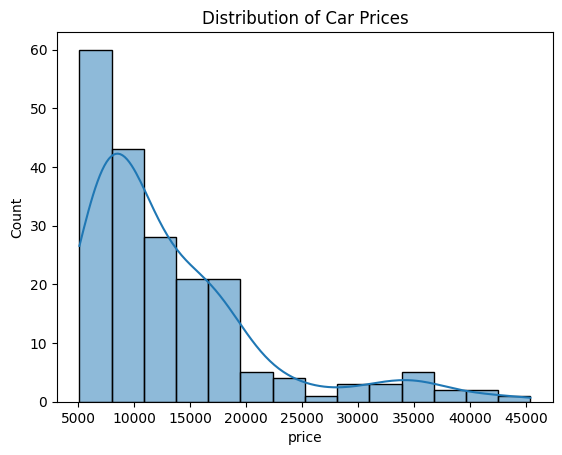

In [2]:
# WHY: Understand how price is distributed (skewed, normal, outliers)

plt.figure()
sns.histplot(df['price'], kde=True)
plt.title("Distribution of Car Prices")
plt.show()

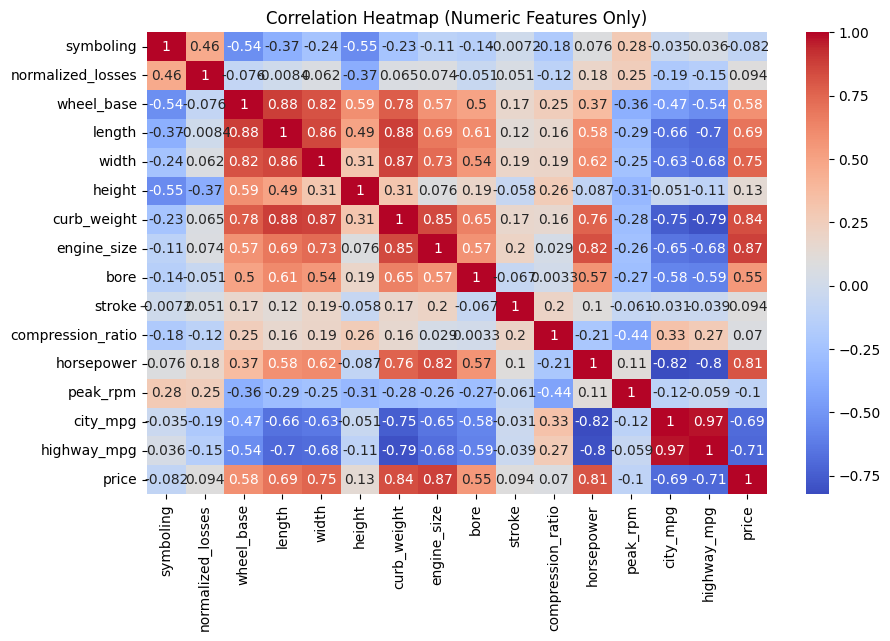

In [4]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)

plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

In [5]:
# WHY: Compare mean price between two groups (e.g., diesel vs petrol)
# Helps check if difference is statistically significant

# Create groups
petrol = df[df['fuel_type_gas'] == 1]['price']
diesel = df[df['fuel_type_gas'] == 0]['price']

# Perform t-test
t_stat, p_value = ttest_ind(petrol, diesel, nan_policy='omit')

print("T-test statistic:", t_stat)
print("P-value:", p_value)

# Interpretation:
# If p-value < 0.05 → significant difference in prices

T-test statistic: -1.5387478581114913
P-value: 0.12547051091846334


In [6]:
# WHY: Compare mean price across multiple categories (e.g., drive types)
# Used when more than 2 groups exist

group1 = df[df['drive_wheels'] == 'fwd']['price']
group2 = df[df['drive_wheels'] == 'rwd']['price']
group3 = df[df['drive_wheels'] == '4wd']['price']

f_stat, p_value = f_oneway(group1, group2, group3)

print("ANOVA F-statistic:", f_stat)
print("P-value:", p_value)

# Interpretation:
# If p-value < 0.05 → at least one group differs significantly

ANOVA F-statistic: 66.92990285052078
P-value: 6.995421830700136e-23


In [12]:
df_original = pd.read_csv("cleaned_auto_data.csv") #loaded data again as Chi-square requires categorical variables in their original form

In [13]:
contingency_table = pd.crosstab(
    df_original['drive_wheels'],
    df_original['body_style']
)

from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)

Chi-square statistic: 18.38107235111323
P-value: 0.018544113588652624


In [14]:
# WHY: Choose variables that influence price

features = ['horsepower', 'engine_size', 'curb_weight', 'city_mpg']
target = 'price'

X = df[features]
y = df[target]

In [15]:
# WHY: Evaluate model performance on unseen data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# WHY: Build a model to predict price

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [17]:
# Predict on test data
y_pred = model.predict(X_test)

In [18]:
# WHY: Measure how well model performs

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R-squared:", r2)
print("RMSE:", rmse)

# Interpretation:
# R² → % of variance explained (higher is better)
# RMSE → average prediction error (lower is better)

R-squared: 0.7757501764397818
RMSE: 5035.299676117043


In [19]:
# WHY: Understand which features impact price most

coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

print(coefficients)

       Feature  Coefficient
0   horsepower    32.443851
1  engine_size    82.313350
2  curb_weight     3.801638
3     city_mpg   -50.047671


In [20]:
print("Petrol n:", petrol.dropna().shape[0], "mean:", petrol.mean(), "std:", petrol.std())
print("Diesel n:", diesel.dropna().shape[0], "mean:", diesel.mean(), "std:", diesel.std())

Petrol n: 179 mean: 12953.519553072625 std: 7971.455788364599
Diesel n: 20 mean: 15838.15 std: 7759.8437129880385


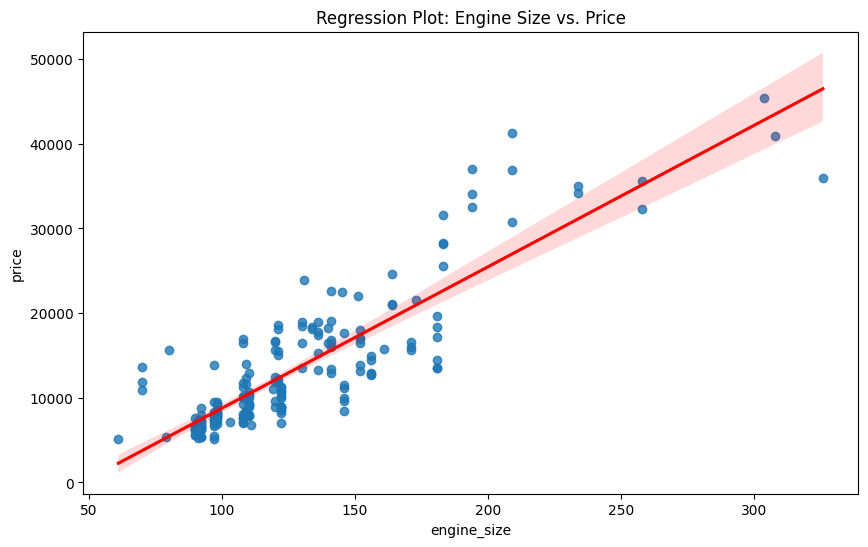

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data again so Python knows what 'df' is
df = pd.read_csv("cleaned_auto_data_final.csv")

# 2. Now run the plot
plt.figure(figsize=(10, 6))
sns.regplot(x='engine_size', y='price', data=df, line_kws={"color": "red"})
plt.title("Regression Plot: Engine Size vs. Price")
plt.show()